## PCA on iris data

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data          # Shape = (150, 4)
y = iris.target

print("Original Shape:", X.shape)

Original Shape: (150, 4)


In [ ]:
# Step 1: Standardize the Data (Mean = 0, Variance = 1)

mean = np.mean(X, axis=0)   # mean per feature (column-wise mean)
std = np.std(X, axis=0)      # standard deviation per feature (column-wise std)

X_standardized = (X - mean) / std

In [26]:
# Step 2: Compute Covariance Matrix

cov_matrix = np.cov(X_standardized.T)

print("\nCovariance Matrix:")
print(cov_matrix)


Covariance Matrix:
[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


In [27]:
# Step 3: Compute Eigenvalues and Eigenvectors

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("\nEigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)


Eigenvalues:
[2.93808505 0.9201649  0.14774182 0.02085386]

Eigenvectors:
[[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


In [28]:
# Step 4: Sort Eigenvalues in Descending Order

sorted_indices = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

print("\nSorted Eigenvalues:")
print(eigenvalues)


Sorted Eigenvalues:
[2.93808505 0.9201649  0.14774182 0.02085386]


In [29]:
# Step 5: Select Top k Principal Components and Project Data

k = 2

principal_components = eigenvectors[:, :k]

print("\nPrincipal Components:")
print(principal_components)

X_pca = np.dot(X_standardized, principal_components)

print("\nReduced Shape:", X_pca.shape)


Principal Components:
[[ 0.52106591 -0.37741762]
 [-0.26934744 -0.92329566]
 [ 0.5804131  -0.02449161]
 [ 0.56485654 -0.06694199]]

Reduced Shape: (150, 2)



Explained Variance Ratio:
PC1: 0.7296
PC2: 0.2285
PC3: 0.0367
PC4: 0.0052

Total variance captured by first 2 PCs: 0.9581320720000165


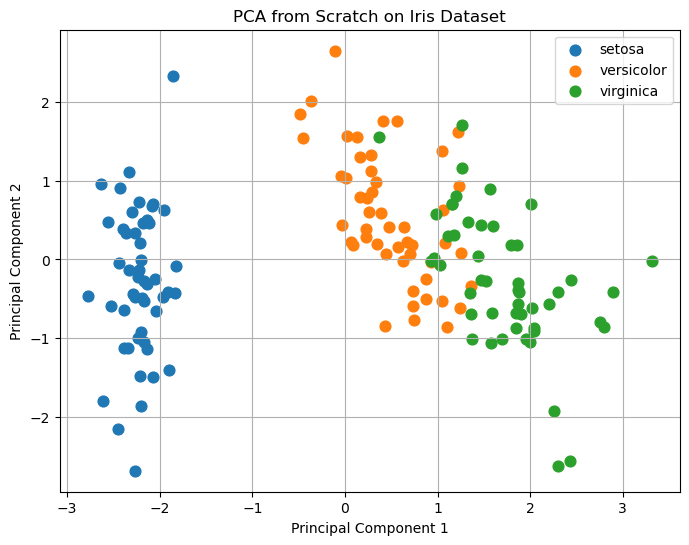

In [30]:
# Step 6: Explained Variance Ratio

explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

print("\nExplained Variance Ratio:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC{i+1}: {ratio:.4f}")

print("\nTotal variance captured by first 2 PCs:", np.sum(explained_variance_ratio[:2]))

colors = ['red', 'green', 'blue']
labels = iris.target_names

plt.figure(figsize=(8,6))

for i in range(3):
    plt.scatter(
        X_pca[y==i,0],
        X_pca[y==i,1],
        label=labels[i],
        s=60
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA from Scratch on Iris Dataset")
plt.legend()
plt.grid(True)
plt.show()

## LDA on iris data

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

print("Original Shape:", X.shape)

overall_mean = np.mean(X, axis=0)

n_features = X.shape[1]

Sw = np.zeros((n_features, n_features))
Sb = np.zeros((n_features, n_features))

classes = np.unique(y)

Original Shape: (150, 4)


In [32]:
# Step 1: Compute Within-Class Scatter Matrix

for c in classes:

    X_c = X[y == c]

    class_mean = np.mean(X_c, axis=0)

    X_centered = X_c - class_mean

    Sw += X_centered.T @ X_centered

print("\nWithin-Class Scatter Matrix:")
print(Sw)


Within-Class Scatter Matrix:
[[38.9562 13.63   24.6246  5.645 ]
 [13.63   16.962   8.1208  4.8084]
 [24.6246  8.1208 27.2226  6.2718]
 [ 5.645   4.8084  6.2718  6.1566]]


In [33]:
# Step 4: Compute Between-Class Scatter Matrix

for c in classes:

    X_c = X[y == c]

    class_mean = np.mean(X_c, axis=0)

    n_c = X_c.shape[0]

    mean_diff = (class_mean - overall_mean).reshape(-1,1)

    Sb += n_c * (mean_diff @ mean_diff.T)

print("\nBetween-Class Scatter Matrix:")
print(Sb)


Between-Class Scatter Matrix:
[[ 63.21213333 -19.95266667 165.2484      71.27933333]
 [-19.95266667  11.34493333 -57.2396     -22.93266667]
 [165.2484     -57.2396     437.1028     186.774     ]
 [ 71.27933333 -22.93266667 186.774       80.41333333]]


In [34]:
# Step 3: Solve Eigenvalue Problem

A = np.linalg.inv(Sw) @ Sb

eigenvalues, eigenvectors = np.linalg.eig(A)
print("eigenvalues : \n", eigenvalues)
print("eigenvectors :\n", eigenvectors)

eigenvalues : 
 [ 3.21919292e+01  2.85391043e-01  2.57837717e-15 -6.47046025e-15]
eigenvectors :
 [[ 0.20874182 -0.00653196  0.88511522 -0.4387109 ]
 [ 0.38620369 -0.58661055 -0.29534777  0.43667301]
 [-0.55401172  0.25256154 -0.27351658  0.48650223]
 [-0.7073504  -0.76945309 -0.23351537 -0.61657523]]


In [35]:
# Step 4: Sort Eigenvalues

sorted_indices = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

print("\nEigenvalues:")
print(eigenvalues)


Eigenvalues:
[ 3.21919292e+01  2.85391043e-01  2.57837717e-15 -6.47046025e-15]


In [36]:
# Step 5: Select Top Components and Project Data

k = 2

W = eigenvectors[:, :k]

X_lda = X @ W

print("\nReduced Shape:", X_lda.shape)


Reduced Shape: (150, 2)



Discriminant Importance
LD1: 0.9912
LD2: 0.0088
LD3: 0.0000
LD4: -0.0000

Total captured by first two: 1.0


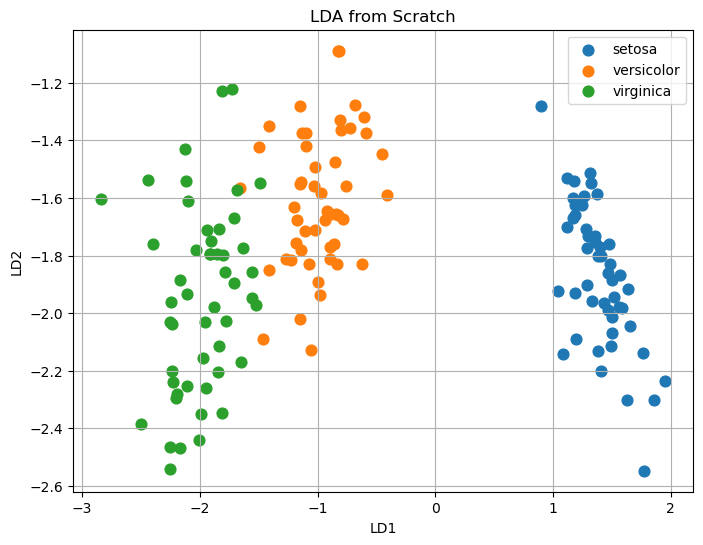

In [37]:
# Step 6: Contribution of Each Discriminant

explained = eigenvalues / np.sum(eigenvalues)

print("\nDiscriminant Importance")

for i in range(len(explained)):
    print(f"LD{i+1}: {explained[i]:.4f}")

print("\nTotal captured by first two:",
      np.sum(explained[:2]))


colors = ['red','green','blue']
labels = iris.target_names

plt.figure(figsize=(8,6))

for i in range(3):

    plt.scatter(
        X_lda[y==i,0],
        X_lda[y==i,1],
        s=60,
        label=labels[i]
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA from Scratch")
plt.legend()
plt.grid(True)
plt.show()